In [1]:
from carvana.models.unet import UNet
from torch.utils.data import DataLoader, random_split
import segmentation_models_pytorch as smp
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..', '..')))

from carvana.config import *
from carvana.dataset.dataset import CarvanaDataset
from carvana.dataset.transforms import get_transforms
from carvana.train.losses import *
from carvana.train.trainer import run_training
from carvana.train.utils import *

/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_transform = get_transforms(image_size=IMAGE_SIZE, is_train=True)
val_transform = get_transforms(image_size=IMAGE_SIZE, is_train=False)

full_dataset = CarvanaDataset(
    images_dir=TRAIN_IMAGES_DIR,
    masks_dir=TRAIN_MASKS_DIR,
    normalize_mask=True
)

/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [3]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

In [4]:
train_subset.dataset.transform = train_transform
val_subset.dataset.transform = val_transform

In [5]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
model = UNet().to(DEVICE)

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss = DiceLoss()

Training: 100%|██████████| 255/255 [11:23<00:00,  2.68s/it, iou=0.969, loss=0.159]


[*] Лучшая модель сохранена (IoU: 0.9708)
Epoch 01 | Val Loss: 0.1613 | IoU: 0.9708 | Dice: 0.9852


Training: 100%|██████████| 255/255 [13:04<00:00,  3.08s/it, iou=0.97, loss=0.0748] 


[*] Лучшая модель сохранена (IoU: 0.9772)
Epoch 02 | Val Loss: 0.0887 | IoU: 0.9772 | Dice: 0.9884


Training: 100%|██████████| 255/255 [11:58<00:00,  2.82s/it, iou=0.978, loss=0.0634]


...

[*] Лучшая модель сохранена (IoU: 0.9859)
[EarlyStopping] Счетчик: 1 из 3
Epoch 09 | Val Loss: 0.0132 | IoU: 0.9859 | Dice: 0.9929


Training: 100%|██████████| 255/255 [11:24<00:00,  2.69s/it, iou=0.987, loss=0.0102]


[*] Лучшая модель сохранена (IoU: 0.9866)
[EarlyStopping] Счетчик: 2 из 3
Epoch 10 | Val Loss: 0.0113 | IoU: 0.9866 | Dice: 0.9932


Training: 100%|██████████| 255/255 [11:34<00:00,  2.73s/it, iou=0.987, loss=0.0111] 


[*] Лучшая модель сохранена (IoU: 0.9870)
[EarlyStopping] Счетчик: 3 из 3
Ранняя остановка на 11 эпохе


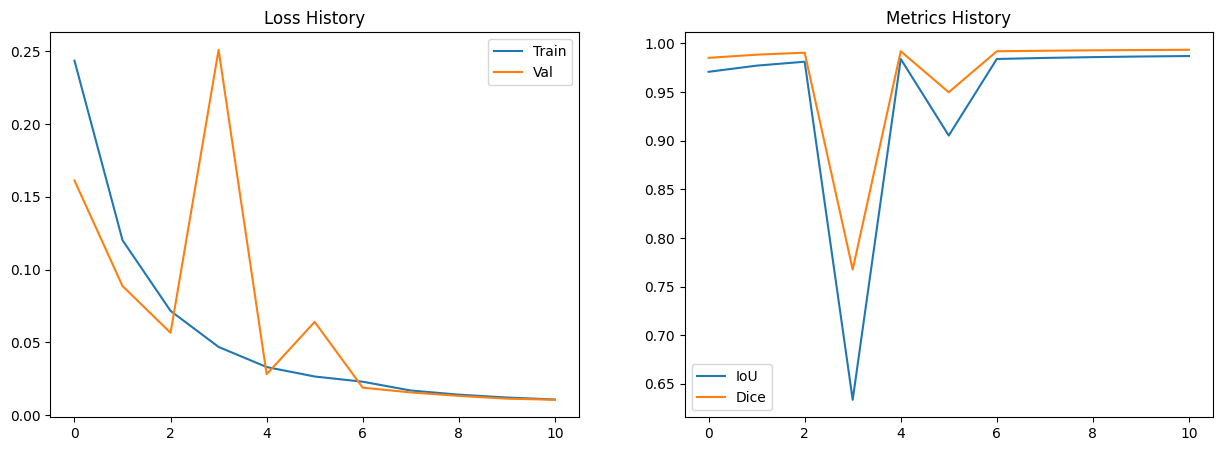

In [8]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss,
    device=DEVICE,
    epochs=NUM_EPOCHS,
    save_dir='../outputs',
    model_name='my_unet'
)